### Imports

In [1]:
# Imports
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2
import dataprep as dp

/Users/mds/Documents/MSc/10_Project/product-sales/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Stylise the plots
These settings are taken from Géron's HOML PyTorch

In [2]:
# Make plots look a bit nicer
# Settings taken from Géron's HOML
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Load data

In [3]:
# Download latest version of Visuelle dataset
path = kagglehub.dataset_download("konradb/visuelle-complete-dataset")

def load_visuelle():
    return pd.read_csv(path + '/train.csv')

df_raw = load_visuelle()
df = df_raw.copy()

In [4]:
def load_test():
    return pd.read_csv(path + '/test.csv')

test_raw = load_test()
test = test_raw.copy()

## Initial Data Analysis

In [5]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,external_code,day,week,month,year
count,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000
mean,0.014884,0.051102,0.058264,0.056137,0.054268,0.053161,0.050315,0.046183,0.041616,0.037107,0.030973,0.027149,2540.500000,0.526575,0.499440,0.535105,0.999445
std,0.023272,0.050550,0.052228,0.050573,0.050793,0.054166,0.056004,0.057796,0.055524,0.055351,0.048515,0.048246,1466.614014,0.284090,0.282472,0.281798,0.000409
min,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000939,0.000000,0.000000,0.000000,-0.001878,-0.000939,0.000000,1.000000,0.000000,0.019231,0.083333,0.998514
25%,0.002817,0.017840,0.022535,0.021596,0.021596,0.019718,0.018779,0.015962,0.012207,0.009390,0.006573,0.004695,1270.750000,0.333333,0.230769,0.250000,0.999009
50%,0.006573,0.037559,0.044131,0.044131,0.041315,0.037559,0.033803,0.030047,0.025352,0.021596,0.016901,0.014085,2540.500000,0.500000,0.538462,0.583333,0.999505
75%,0.017840,0.066667,0.079812,0.074178,0.069484,0.067606,0.061033,0.053521,0.047887,0.043192,0.036620,0.030986,3810.250000,0.666667,0.730769,0.750000,1.000000
max,0.512676,0.763380,0.460094,0.596244,0.628169,0.739906,0.684507,0.998122,0.615962,1.000000,0.921127,0.905164,5080.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
print("Shape:", df.shape)
print ("Columns:", df.columns)

df.info()

Shape: (5080, 24)
Columns: Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       'external_code', 'season', 'category', 'release_date', 'day', 'week',
       'month', 'year', 'image_path', 'color', 'fabric', 'extra'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5080 entries, 0 to 5079
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   0              5080 non-null   float64
 1   1              5080 non-null   float64
 2   2              5080 non-null   float64
 3   3              5080 non-null   float64
 4   4              5080 non-null   float64
 5   5              5080 non-null   float64
 6   6              5080 non-null   float64
 7   7              5080 non-null   float64
 8   8              5080 non-null   float64
 9   9              5080 non-null   float64
 10  10             5080 non-null   float64
 11  11             5080 non-null   float64
 12  external_c

In [7]:
float_cols = df.select_dtypes(include='float64').columns

# Check for any values outside of normalisation range
df[float_cols].describe().T[['min', 'max']]

,min,max
0,0.000000,0.512676
1,0.000000,0.763380
2,0.000000,0.460094
3,0.000000,0.596244
4,0.000000,0.628169
5,-0.000939,0.739906
6,0.000000,0.684507
7,0.000000,0.998122
8,0.000000,0.615962
9,-0.001878,1.000000


In [8]:
# Remove outlying values
df[float_cols] = df[float_cols].clip(0, 1)

df[float_cols].describe().T[['min', 'max']]

,min,max
0,0.000000,0.512676
1,0.000000,0.763380
2,0.000000,0.460094
3,0.000000,0.596244
4,0.000000,0.628169
5,0.000000,0.739906
6,0.000000,0.684507
7,0.000000,0.998122
8,0.000000,0.615962
9,0.000000,1.000000


In [9]:
# Will reuse week_cols and weeks
weeks = range(12)
week_cols = [f"W{w + 1:02d}" for w in weeks]

df = dp.rename_weeks(df)

## Exploratory Data Analysis

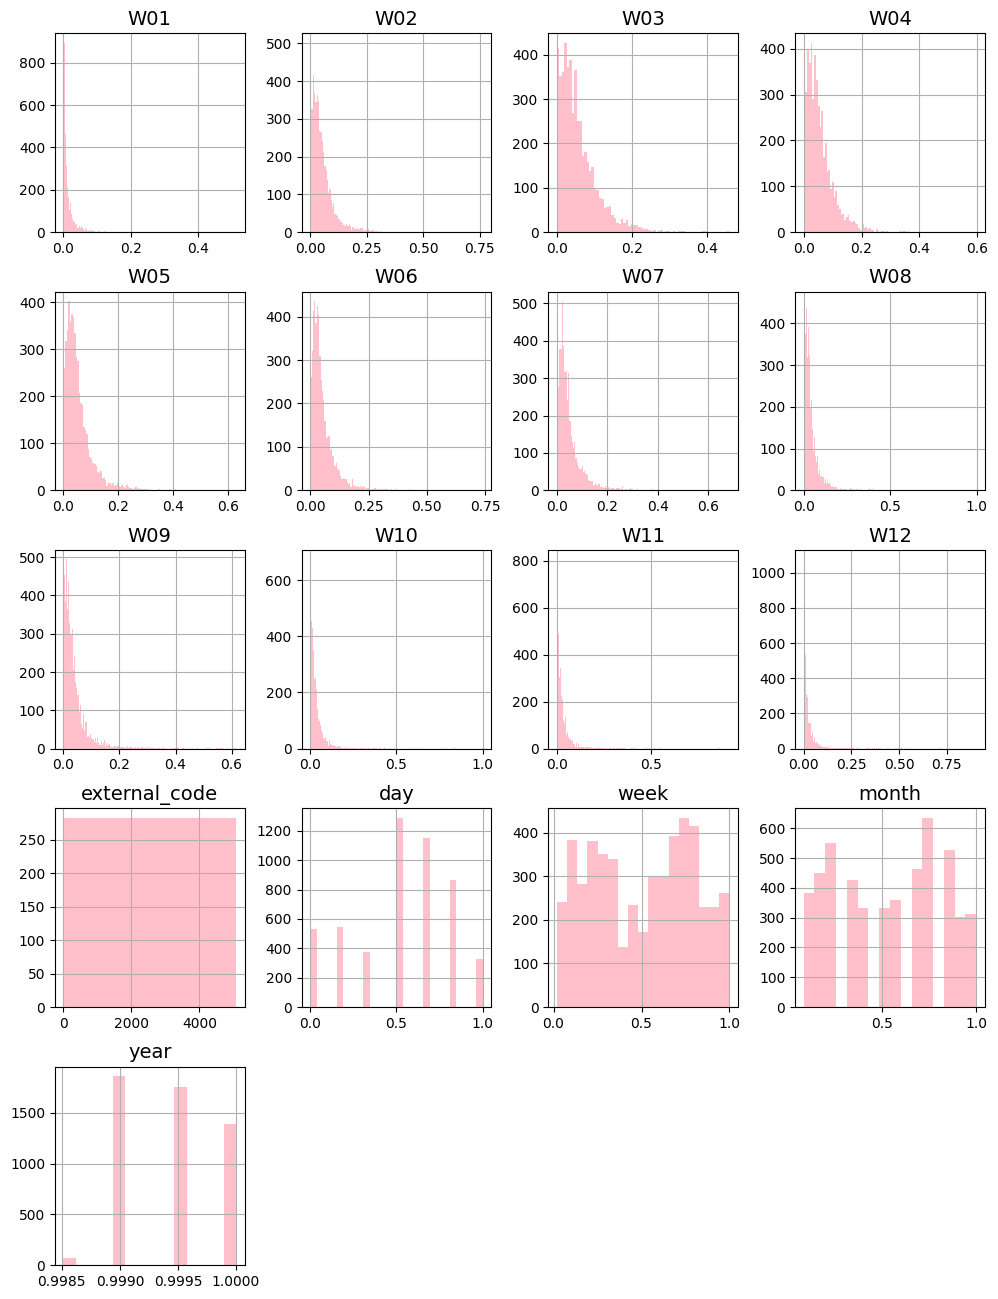

In [10]:
# Histogram for each numerical value
df.hist(bins='auto', figsize=(12, 16), color='pink')
plt.title('Histogram for numerical values')
plt.show()

### Get a better idea of what the data looks like across the 12 weeks

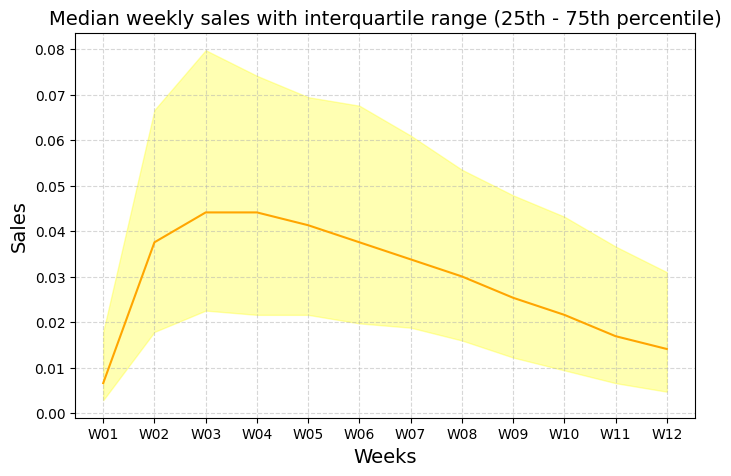

In [11]:
# Plot sales across the 12 weeks
# Interquartile range (25–75)
# IQR = Q₃ - Q₁
# Shows the range of the middle 50% of the dataset
median_sales = df[week_cols].median()

q1 = df[week_cols].quantile(0.25)
q3 = df[week_cols].quantile(0.75)

plt.figure(figsize=(8, 5))

plt.plot(weeks, median_sales, color='orange', label='Median')
plt.fill_between(weeks, q1, q3, alpha=0.3, color='yellow', label='IQR (25th-75th)')

plt.xlabel('Weeks')
plt.xticks(weeks, week_cols)
plt.ylabel('Sales')
plt.title('Median weekly sales with interquartile range (25th - 75th percentile)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Deciles plots
Split the data into sales deciles and plot each decile's sales across the 12 weeks
This is intended to give me a better idea of the differences in sales across the whole product performance spectrum
And also the amount of products that belongs in each decile

In [12]:
df = dp.sum_weeks(df, week_cols)

# Split into 10s
df['decile'] = pd.qcut(df['total_sales_12'], 10, labels=False, retbins=False, precision=3, duplicates='raise')

# Check split was successful
print(df['decile'].value_counts())

decile
2    510
6    509
0    509
4    508
9    508
5    508
8    508
7    507
1    507
3    506
Name: count, dtype: int64


In [13]:
# Print table of the means
decile_means = df.groupby('decile')[week_cols].mean()
print(decile_means)

             W01       W02       W03       W04       W05       W06       W07  \
decile                                                                         
0       0.004658  0.008676  0.008816  0.007991  0.007172  0.006661  0.006434   
1       0.007991  0.018314  0.019741  0.018105  0.016972  0.015749  0.015574   
2       0.009997  0.025630  0.026632  0.026396  0.024989  0.023553  0.022014   
3       0.011448  0.032135  0.034768  0.033560  0.031506  0.029574  0.027262   
4       0.014195  0.040814  0.044117  0.042444  0.039705  0.036823  0.032936   
5       0.014210  0.048848  0.055443  0.051188  0.047597  0.044189  0.039716   
6       0.018279  0.055978  0.065289  0.061166  0.056030  0.053128  0.049549   
7       0.018322  0.067322  0.078573  0.075658  0.070491  0.068578  0.060772   
8       0.018055  0.079960  0.099898  0.097375  0.094154  0.090681  0.080908   
9       0.031698  0.133409  0.149445  0.147568  0.154142  0.162750  0.168047   

             W08       W09       W10   

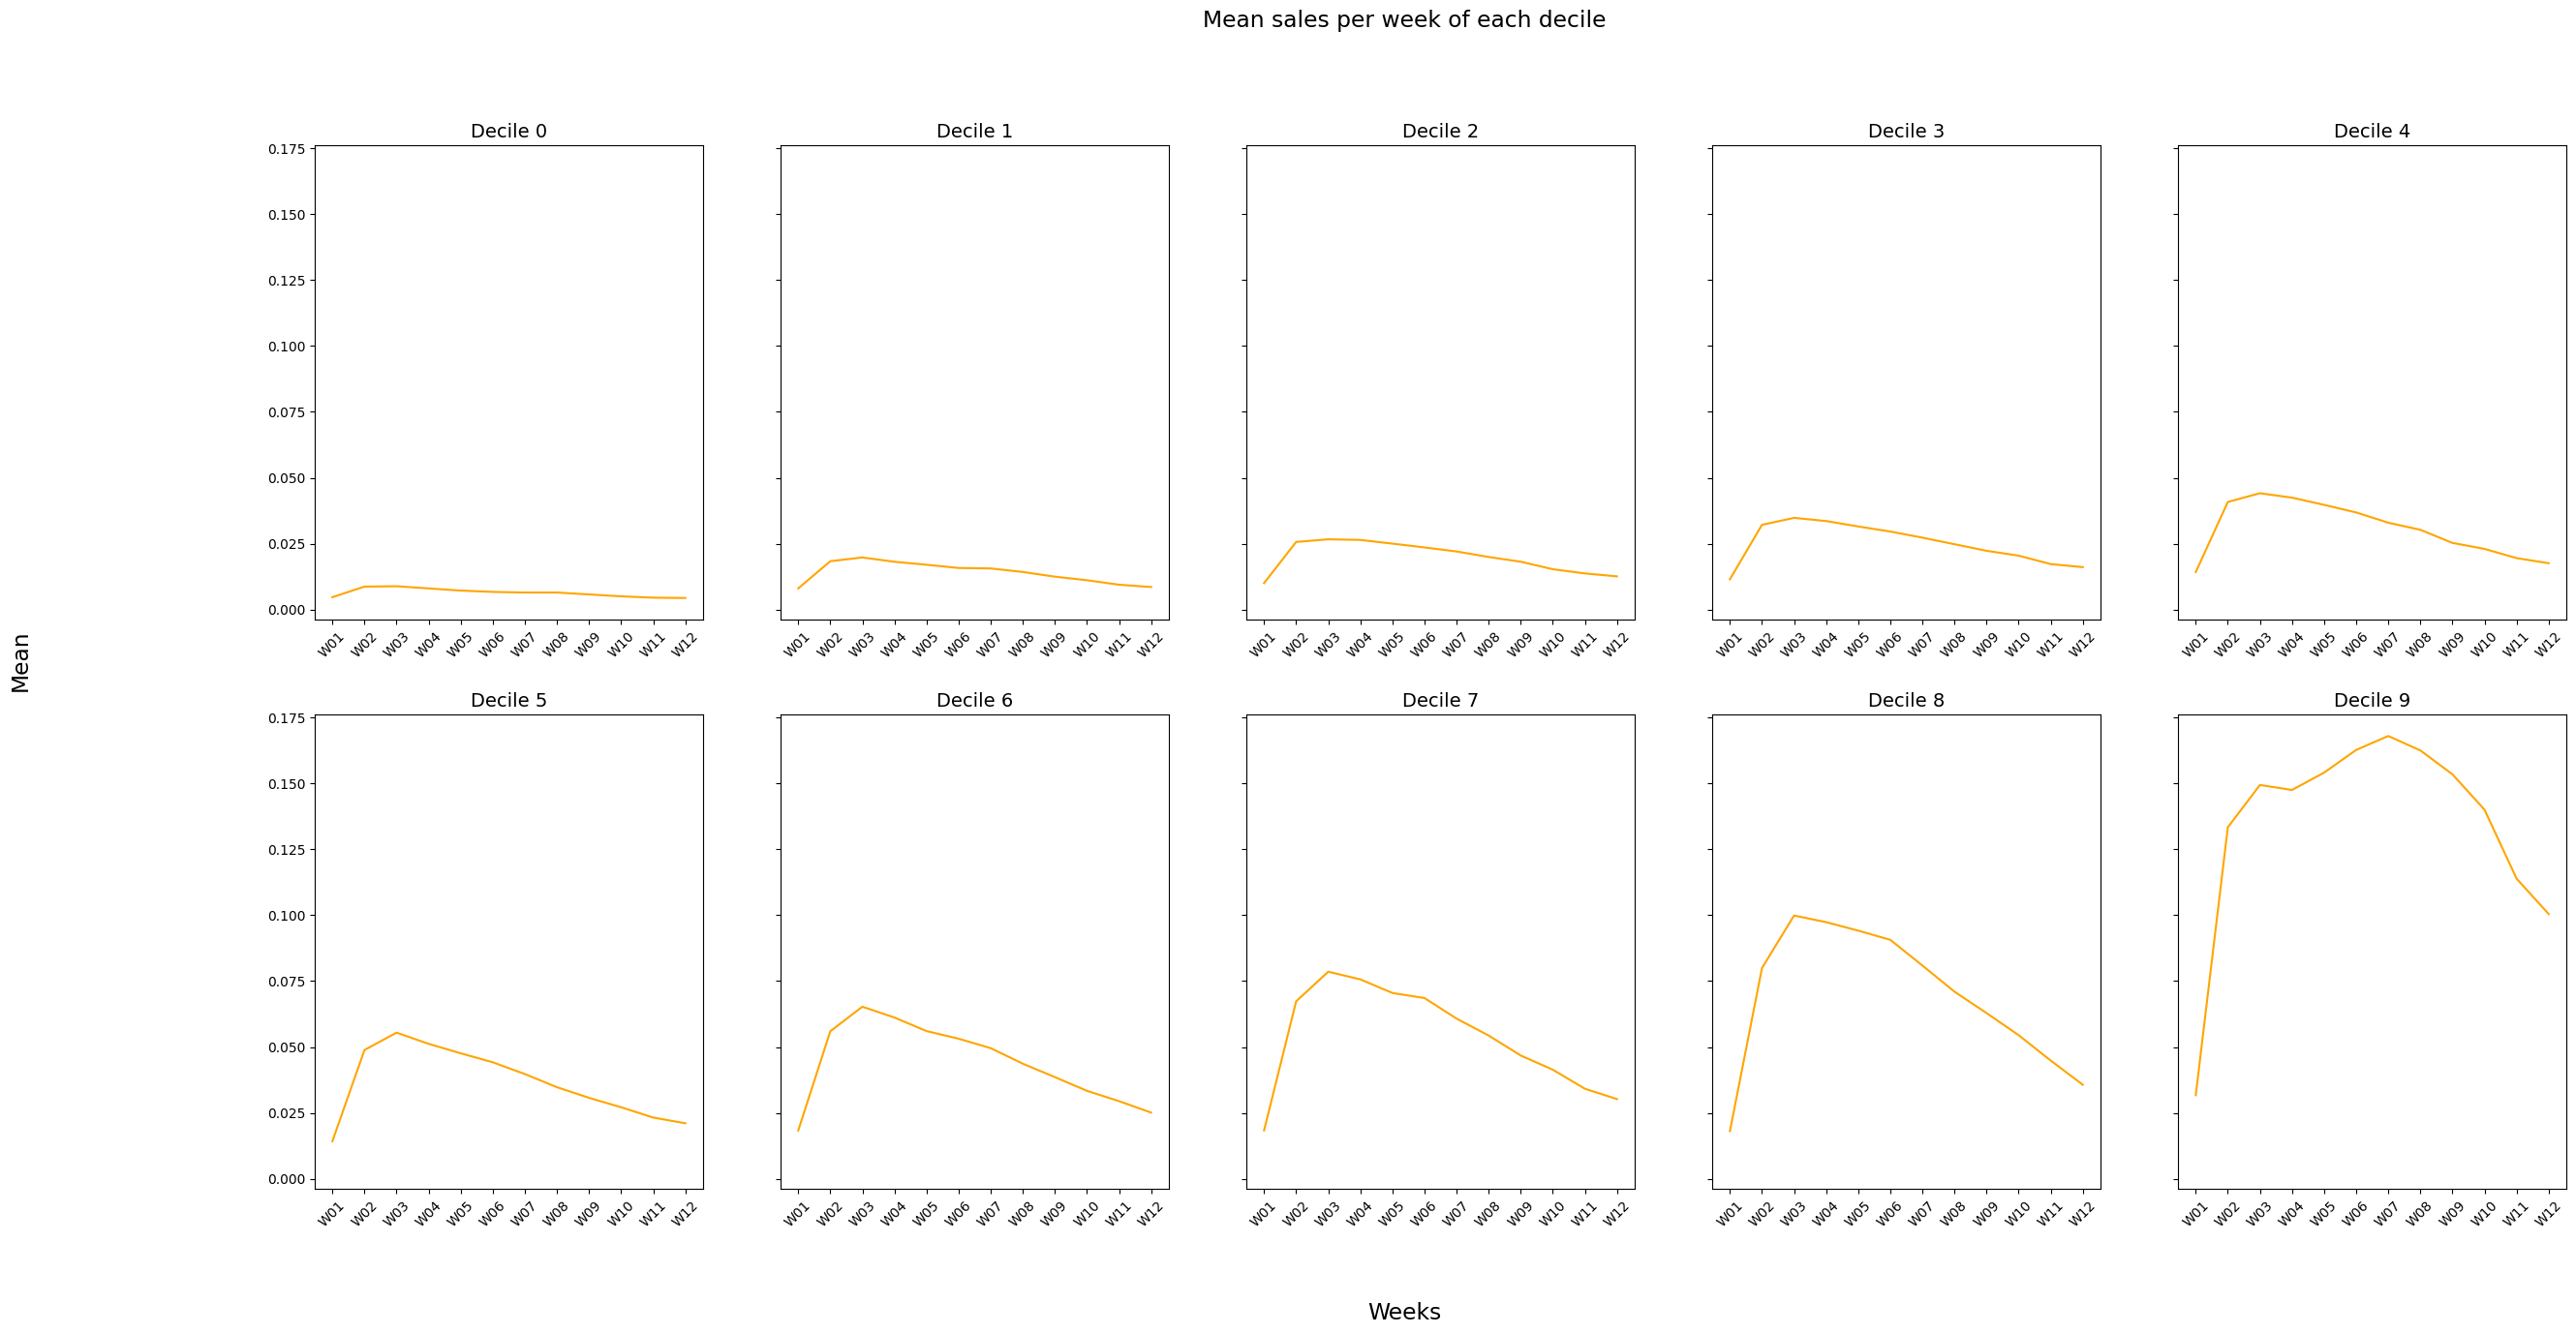

In [14]:
# Prepare and get plots
fig, axes = plt.subplots(2, 5, sharey=True, figsize=(30, 14))

for decile, ax in zip(decile_means.index, axes.flat):
    ax.plot(weeks, decile_means.loc[decile], color='orange')
    ax.set_xticks(weeks, week_cols)
    ax.set_title(f'Decile {decile}')
    ax.tick_params(axis='x', rotation=45)

fig.supxlabel('Weeks')
fig.supylabel('Mean')
fig.suptitle('Mean sales per week of each decile')
plt.show()

Sanity check on the decile summary;
A mean curve per decile could hide the fact that series within a decile behave quite differently.
Plotting the median with an IQR band to show how much spread sits behind each decile's summary curve.

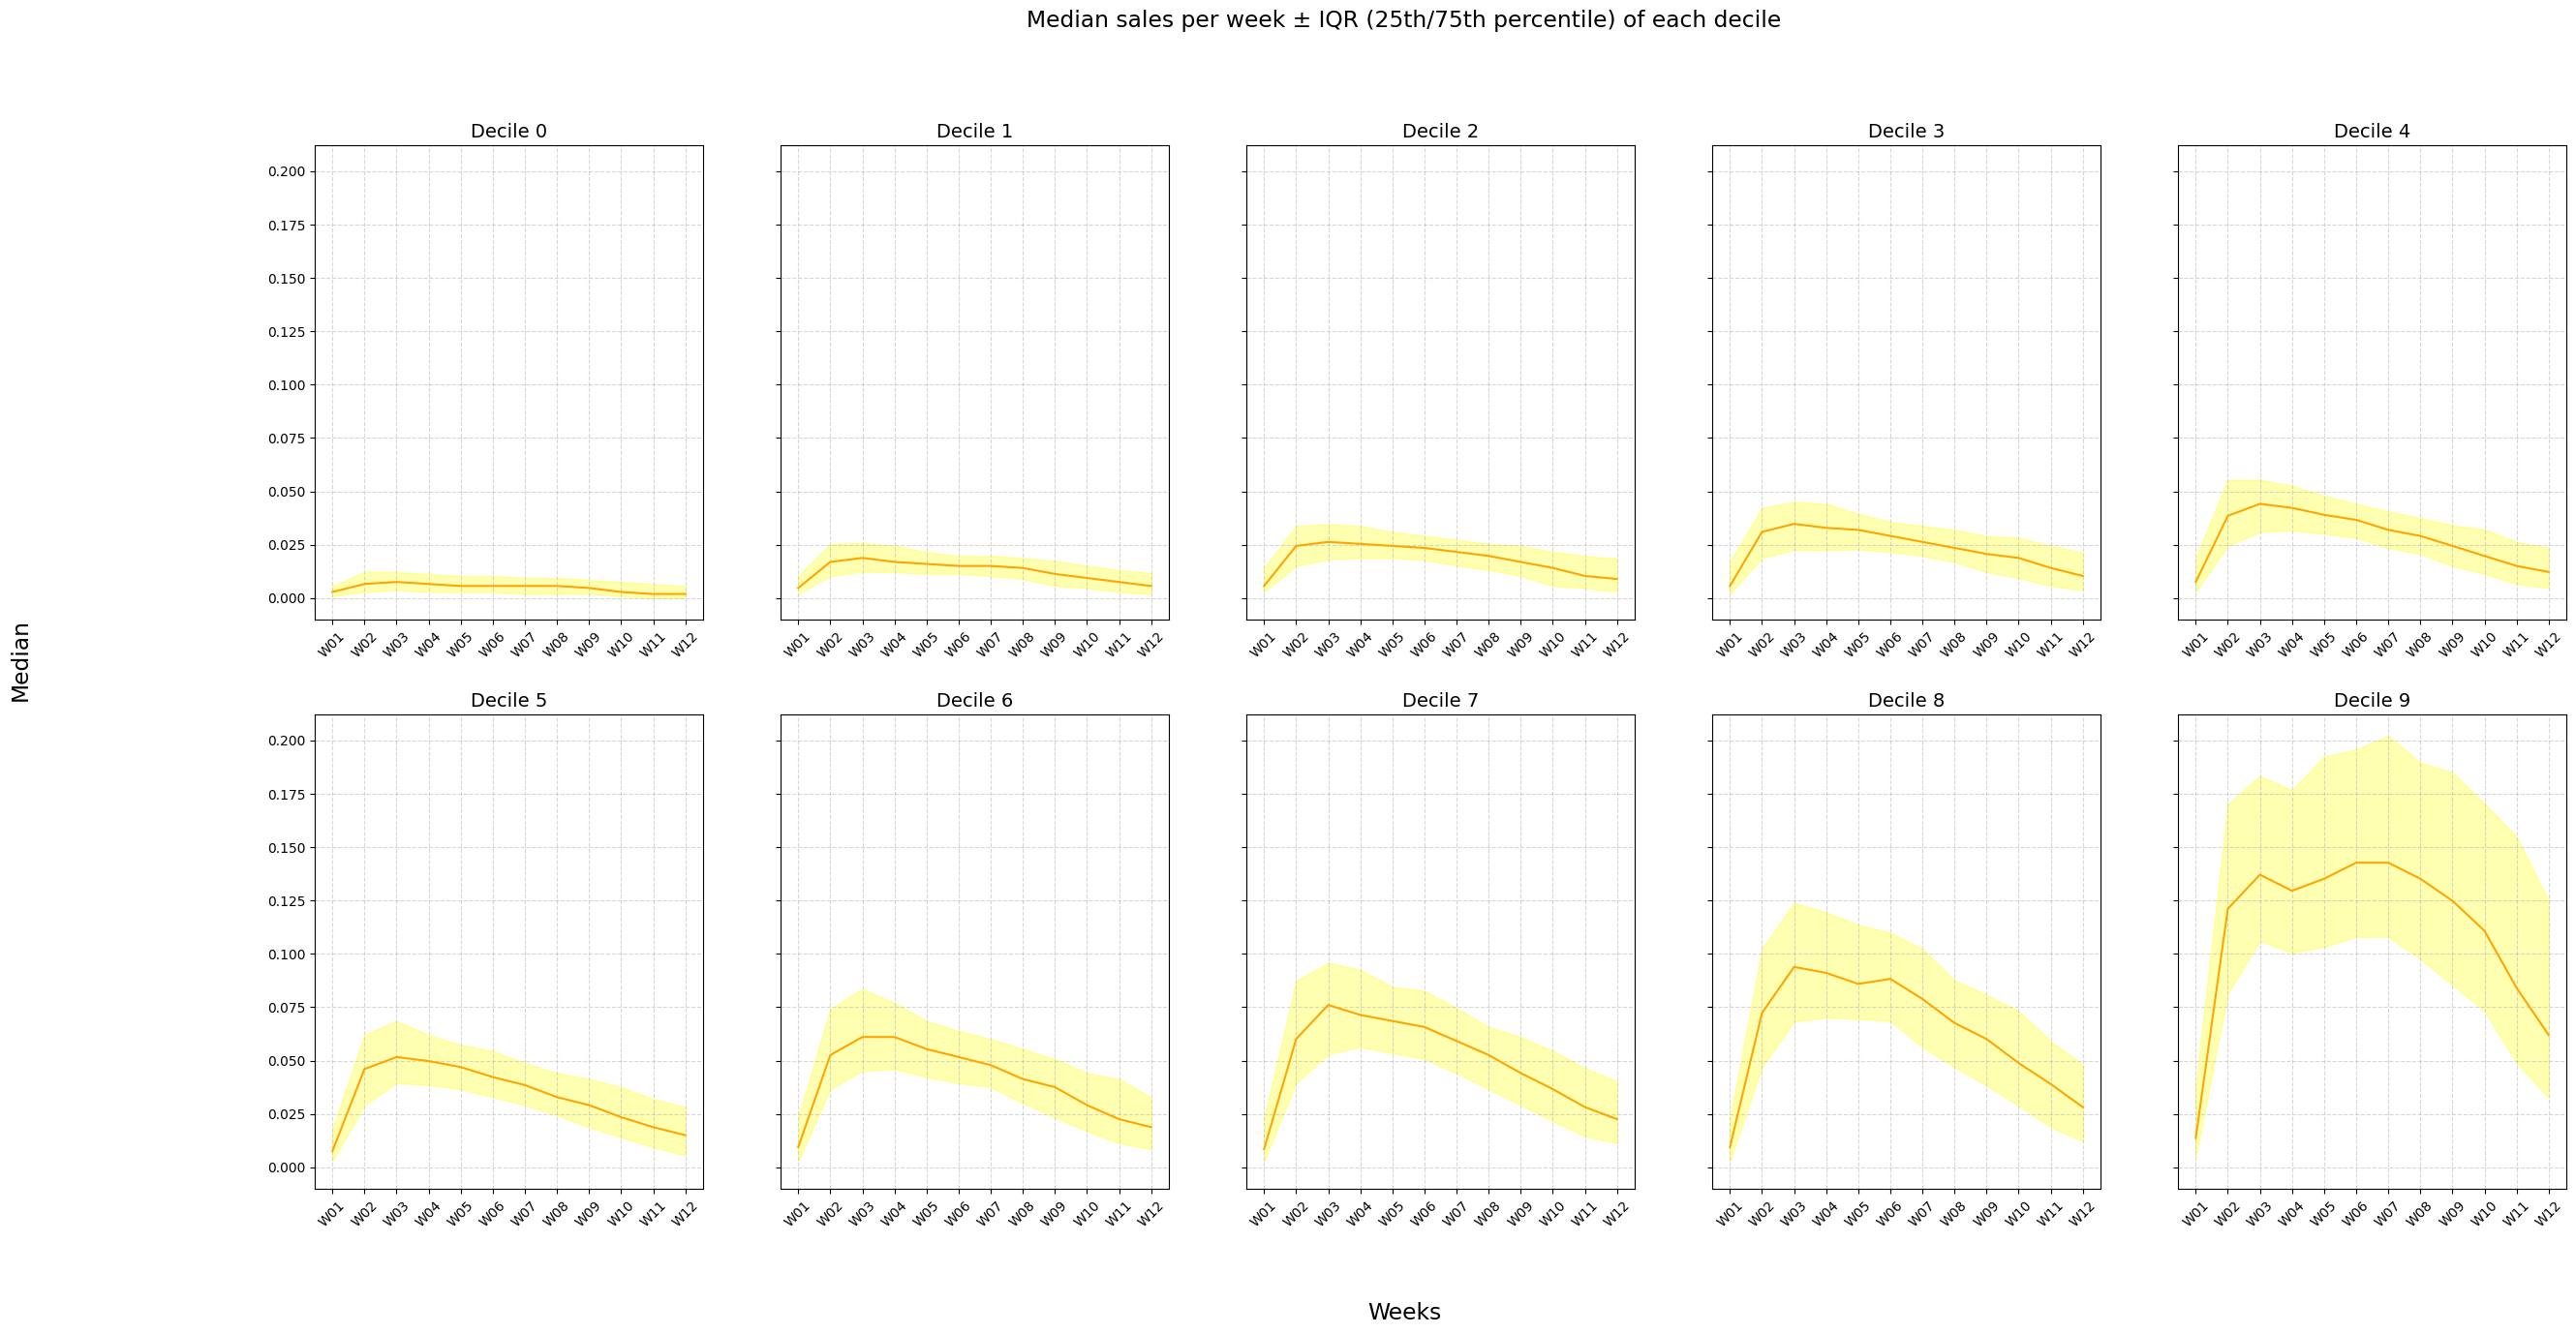

In [15]:
decile_medians = df.groupby('decile')[week_cols].median()
decile_q1 = df.groupby('decile')[week_cols].quantile(0.25)
decile_q3 = df.groupby('decile')[week_cols].quantile(0.75)

fig, axes = plt.subplots(2, 5, sharey=True, figsize=(30, 14))

for decile, ax in zip(decile_medians.index, axes.flat):
    # central tendency
    ax.plot(weeks, decile_medians.loc[decile], color='orange')
    # middle 50% of the decile
    ax.fill_between(weeks, decile_q1.loc[decile], decile_q3.loc[decile], alpha=0.3, color='yellow')
    ax.set_xticks(weeks, week_cols)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(f'Decile {decile}')

fig.supxlabel('Weeks')
fig.supylabel('Median')
fig.suptitle('Median sales per week ± IQR (25th/75th percentile) of each decile')
plt.show()

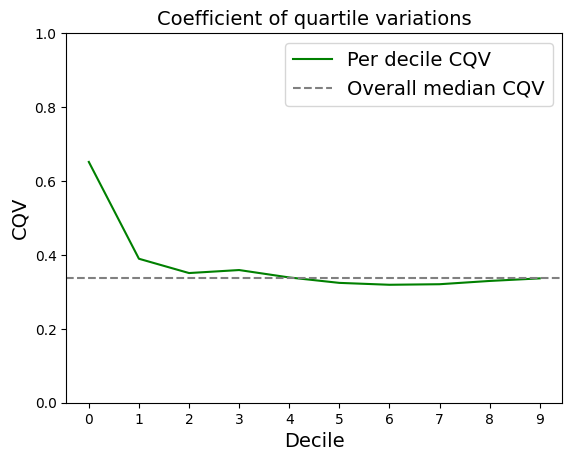

In [16]:
# Follow up to the median / IQR panels since the upper deciles had visibly wider bands,
# but absolute spread grows with sales level by construction.
# A flat line across deciles means the wider bands are just a scale effect

# Check if the larger variation in the higher deciles is due to heteroscedasticity.
# Coefficient of quartile variation
# (Q3−Q1) / (Q3 + Q1)

# one row per (product, week) 
long = (df.reset_index(names='product')
          .melt(id_vars=['product', 'decile'],
                value_vars=week_cols, var_name='week', value_name='sales'))

# unstack turns the three quantile levels into cols, ascending order
q = long.groupby(['decile', 'week'])['sales'].quantile([.25, .5, .75]).unstack()
q.columns = ['q1', 'med', 'q3']
q['qcd'] = (q.q3 - q.q1) / (q.q3 + q.q1)

# collapse the weekly values to one figure per decile;
per_decile = q.groupby('decile')['qcd'].median()
spread = q.groupby('decile')['qcd'].agg(['min', 'max'])

plt.plot(per_decile.index, per_decile, color='green', label='Per decile CQV')

# reference line, any deciles above it are more variable
# relative to their size than typical 
plt.axhline(per_decile.median(), color='grey', linestyle='--', label='Overall median CQV')
plt.ylim(0, 1)

plt.xlabel('Decile')
plt.ylabel('CQV')
plt.xticks(per_decile.index)
plt.title('Coefficient of quartile variations')
plt.legend()
plt.show()

### Season and Category counts
Do an initial rough split of the data (in thirds) to check if any category or season is particularly overrepresented.

Group products into three equal-sized bands by total sales over the 12-week window.
qcut splits on quantiles rather than on value ranges, so that each band holds a third of the products regardless of how skewed the sales distribution is.

In [17]:
# Split into 3rds

df['thirds'] = pd.qcut(df['total_sales_12'], 3, labels=['flat', 'slow', 'fast'], retbins=False, precision=3, duplicates='raise')

# Confirm the three bands come out equally sized
print(df['thirds'].value_counts())

print(df.loc[df['thirds'] == 'flat', 'total_sales_12'].head(10))
print(df.loc[df['thirds'] == 'slow', 'total_sales_12'].head(10))
print(df.loc[df['thirds'] == 'fast', 'total_sales_12'].head(10))

thirds
flat    1696
fast    1694
slow    1690
Name: count, dtype: int64
10    0.125822
12    0.217840
13    0.103286
14    0.184038
16    0.246009
17    0.210329
18    0.271362
19    0.152113
21    0.215962
22    0.217840
Name: total_sales_12, dtype: float64
0     0.387793
3     0.323944
7     0.424413
9     0.415023
20    0.319249
34    0.314554
37    0.293897
43    0.399061
54    0.366197
57    0.320188
Name: total_sales_12, dtype: float64
1     1.065728
2     0.597183
4     0.646948
5     1.255399
6     0.575587
8     0.597183
11    0.859155
15    0.786854
51    0.553991
55    0.745540
Name: total_sales_12, dtype: float64


#### Season confound check

Check how the classes sit within each season.
The flat/show/fast cuts are worked out across all products at once, so a season that happens to sell unusually well will end up holding more of one class than the others.

If an extreme case is found, the model could separate the classes by simply picking season rather than the product iself.

This shows the class breakdown of the seasons side by side so that any extreme case is visible. The spread turned out to be uneven, but not extreme.

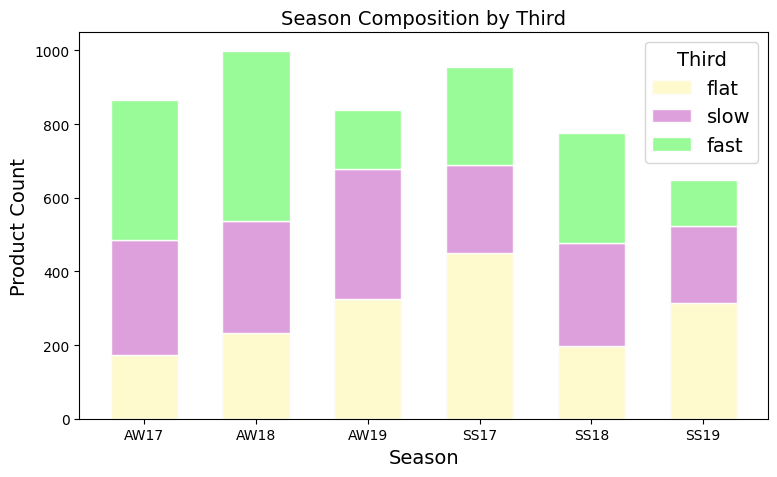

In [18]:
# fixed order and colours
# bands always stack lowest to highest
# same colour in every chart
thirds_order = ['flat', 'slow', 'fast']
thirds_colors = {'flat': '#FFFACD', 'slow': '#DDA0DD', 'fast': '#98FB98'}

# count products in each season/class pair
# one row per season, one col per class
seasons = sorted(df['season'].unique())
counts = df.groupby(['season', 'thirds'], observed=True).size().unstack(fill_value=0).reindex(columns=thirds_order)

fig, ax = plt.subplots(figsize=(8, 5))

# stack the bars manually
# each bar starts at the height the previous one reached
bottom = np.zeros(len(counts))
for third in thirds_order:
    ax.bar(counts.index, counts[third], bottom=bottom, label=third,
           color=thirds_colors[third], edgecolor='#fcfcfb', linewidth=1, width=0.6)
    bottom += counts[third].values

ax.set_xlabel('Season')
ax.set_ylabel('Product Count')
ax.set_title('Season Composition by Third')
ax.legend(title='Third')

plt.tight_layout()
plt.show()

#### Category confound check
Same check across product categories. Category is part of the text feature: if a category is an extreme case, then the class is effectively given away by the category.

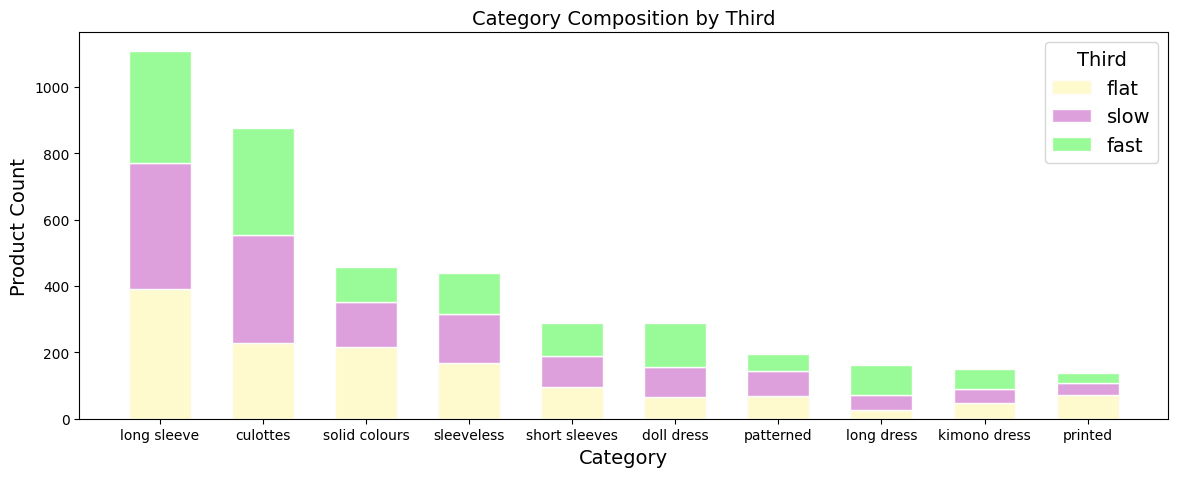

In [19]:
categories = sorted(df['category'].unique())
counts = df.groupby(['category', 'thirds'], observed=True).size().unstack(fill_value=0).reindex(columns=thirds_order)

# only plot the largest 10 categories
# these 10 categories cover more than half the data
top_categories = counts.sum(axis=1).nlargest(10).index
counts = counts.loc[top_categories]

fig, ax = plt.subplots(figsize=(12, 5))

# stack the bars manually like above
# each class starts at the height of the previous one
bottom = np.zeros(len(counts))
for third in thirds_order:
    ax.bar(counts.index, counts[third], bottom=bottom, label=third,
           color=thirds_colors[third], edgecolor='#fcfcfb', linewidth=1, width=0.6)
    bottom += counts[third].values

ax.set_xlabel('Category')
ax.set_ylabel('Product Count')
ax.set_title('Category Composition by Third')
ax.legend(title='Third')

plt.tight_layout()
plt.show()


In [20]:
# Clean up
columns_to_drop = ['total_sales_12', 'decile', 'thirds']

df = df.drop(columns=columns_to_drop)

## Build the target feature

Sum each product's sales over its first six weeks -> 'total_sales_6'
This is the quantity the three classes are later cut from.

Decided to keep 6 weeks: they show the direction that a product is heading. The count of products with zero sales grows considerably from week 7 onwards, so doing a sum of 12 weeks of sales seems to be introducing a lot of noise that isn't helpful for the goal of the task.

'total_sales_6' depends only on a product's own sales, so it's computed once and it says constant.
The class label (flat, slow, fast) depends on where the cut points land.

In [21]:
# Check how many products had zero sales per week
# Result shows an increase in products as the weeks go on, which helps validate the decision to go with Skenderi's approach and drop weeks 6 to 12
for week in week_cols:
    print(week, (df[week] == 0).sum())

W01 76
W02 95
W03 67
W04 49
W05 37
W06 47
W07 42
W08 67
W09 99
W10 158
W11 265
W12 363


In [22]:
# window for the target labels
target_weeks = week_cols[:6]

# add those six weeks into one number per product
# this is where the boundaries are cut from later
df = dp.sum_weeks(df, target_weeks)

# Save to a new file that will contain the target label
df.to_csv('data/train_with_target.csv', index=False)

# Import
csv_filepath = 'data/train_with_target.csv'
train_with_target = pd.read_csv(csv_filepath)

In [23]:
# the four cut points
# global thresholds as they are from the full 5,080 product population
# the test labels are built from these too
cuts = train_with_target["total_sales_6"].quantile(list(dp.quantiles.values()))
thresholds = dict(zip(dp.quantiles, cuts))

# turn the four cut points into edges
edges = [-np.inf,
         thresholds["outer_low"],
         thresholds["inner_low"],
         thresholds["inner_high"],
         thresholds["outer_high"],
         np.inf]

edges

[-inf,
 0.1239436619718307,
 0.172769953051643,
 0.2938967136150232,
 0.384976525821596,
 inf]

In [24]:
# What values are in the buffer zones?
# train_with_target['zone'] = pd.cut(train_with_target['total_sales_6'], edges, labels=False)

train_with_target['zone'] = dp.compute_zones(train_with_target['total_sales_6'], edges)

train_with_target['zone'].value_counts().sort_index()

zone
0    1278
1     630
2    1269
3     633
4    1270
Name: count, dtype: int64

### Buffer zones

Two products either side of a cut can have almost the sale sales but different labels. To avoid training on ambiguous cases, I am applying a modified extreme groups approach.

0-25 percentile         > flat
25-37.5 percentile      > in_buffer
37.5-62.5 percentile    > slow
62.5-75 percentile      > in_buffer
75–100 percentile       > fast

Anything in buffer is dropped for training, but evaluation and test runs on all products to mimic a real-world scenario (= edge cases exist in real life).

In [25]:
# Boolean col to indicate which prods are in the buffer zones
train_with_target['in_buffer'] = train_with_target['zone'].isin([1, 3])

train_with_target['in_buffer'].value_counts().sort_index()

in_buffer
False    3817
True     1263
Name: count, dtype: int64

In [26]:
# Target for evaluation
# Uses the buffer zones as part of the 'slow' range of products

train_with_target['label_eval'] = (
    train_with_target['zone'].map(dp.evaluation_map).astype("Int64")
)

train_with_target['label_eval'].value_counts().sort_index()

label_eval
0    1278
1    2532
2    1270
Name: count, dtype: Int64

In [27]:
# Target for training
# Narrower use of the thresholds

train_with_target['label_train'] = (
    train_with_target['zone'].map(dp.train_map).astype("Int64")
)

train_with_target['label_train'].value_counts().sort_index()

label_train
0    1278
1    1269
2    1270
Name: count, dtype: Int64

In [28]:
train_with_target.to_csv('data/train_with_target.csv', index=False)

train_with_target.columns

Index(['W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08', 'W09', 'W10',
       'W11', 'W12', 'external_code', 'season', 'category', 'release_date',
       'day', 'week', 'month', 'year', 'image_path', 'color', 'fabric',
       'extra', 'total_sales_6', 'zone', 'in_buffer', 'label_eval',
       'label_train'],
      dtype='object')

### Add labels to test data
The labels are based on the thresholds defined from the training data, and are decided based on the thresholds computed from the full 5,080 training data.

This means that what classifies a product as flat, slow, or fast, is unique to this store and to what is 'normal' for this particular business.

In [29]:
test_with_target = test.copy()

test_with_target = dp.rename_weeks(test_with_target)
test_with_target = dp.sum_weeks(test_with_target, target_weeks)

test_with_target.columns

Index(['W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08', 'W09', 'W10',
       'W11', 'W12', 'external_code', 'season', 'category', 'release_date',
       'day', 'week', 'month', 'year', 'image_path', 'color', 'fabric',
       'extra', 'total_sales_6'],
      dtype='object')

In [30]:
test_with_target['zone'] = dp.compute_zones(test_with_target['total_sales_6'], edges)

test_with_target['in_buffer'] = test_with_target['zone'].isin([1, 3])

test_with_target['label_eval'] = (
    test_with_target['zone'].map(dp.evaluation_map).astype("Int64")
)

test_with_target['label_eval'].value_counts().sort_index()

label_eval
0     83
1    286
2    128
Name: count, dtype: Int64

In [31]:
test_with_target['in_buffer'].value_counts().sort_index()

in_buffer
False    360
True     137
Name: count, dtype: int64

In [32]:
test_with_target['zone'].value_counts().sort_index()

zone
0     83
1     56
2    149
3     81
4    128
Name: count, dtype: int64

In [33]:
# Save to a new file that will contain the target label
test_with_target.to_csv('data/test_with_target.csv', index=False)

In [34]:
(test_with_target['total_sales_6'] == 0).sum()

np.int64(0)